In [465]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Data Cleaning

### Observations made seeing the dataset
* The rate column, has three entries :
    1. The rate (like 4.1/5)
    2. No rate, as the restaurant is new, hence NEW is written there.
    3. No rate, as it was not recorded
* In the 'rest_type' column, there are two types of entries:
    1. The type is solo, i.e., just cafe (or) just casual dining etc.
    2. There is a combination of types, i.e., cafe, casual dining.
* Columns such as :
    - Phone Number, URL are columns that have 0 weightage in predicting the rating for a restaurant.
    - listed_in(city) is not used, as we directly will use the location column.
    - dish_liked have a lot of null values, essentially it was supposed to have the most liked dishes of that restaurant. We can also get that from the "reviews_list" column.
    - menu_items was almost empty, and again, we can get an idea about it from the reviews.
    - approx_cost provides cost for 2 people, we will bring it down to per head.
    - rest_types has 24 different restaurant types, and the column listed_in(type) maps them and brings it down to 7 types, however the issue is that the mapping is inconsistent and illogical, especially considering that restaurant types like Bar or Microbrewery being mapped to Delivery doesn't make sense.
    - cuisines have different types of cuisines (104 in total), we will have to reduce it using custom mapping, as nothing is provided in the dataset.
    - reviews_list is a list of tuples, having where we have a review, and how-much the user who posted that review rated the restaurant.

In [466]:
df = pd.read_csv(filepath_or_buffer="Data/Raw/zomato.csv",
                usecols=['name','address','online_order', 'book_table', 'rate', 'votes',
                'location', 'rest_type', 'cuisines',
                'approx_cost(for two people)', 'reviews_list'])
print(f"Shape of the raw dataframe is {df.shape}")
df.head()

Shape of the raw dataframe is (51717, 11)


,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ..."
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din..."
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ..."
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper..."
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ..."


Labelling the online_order and the book_table columns <br>
* 1 -> Yes 
* 0 -> No

In [467]:
df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})
df['book_table'] = df['book_table'].map({'Yes': 1, 'No': 0})
df.head()

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ..."
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din..."
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ..."
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper..."
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ..."


### Analyzing how many restaurants have online ordering and booking table options

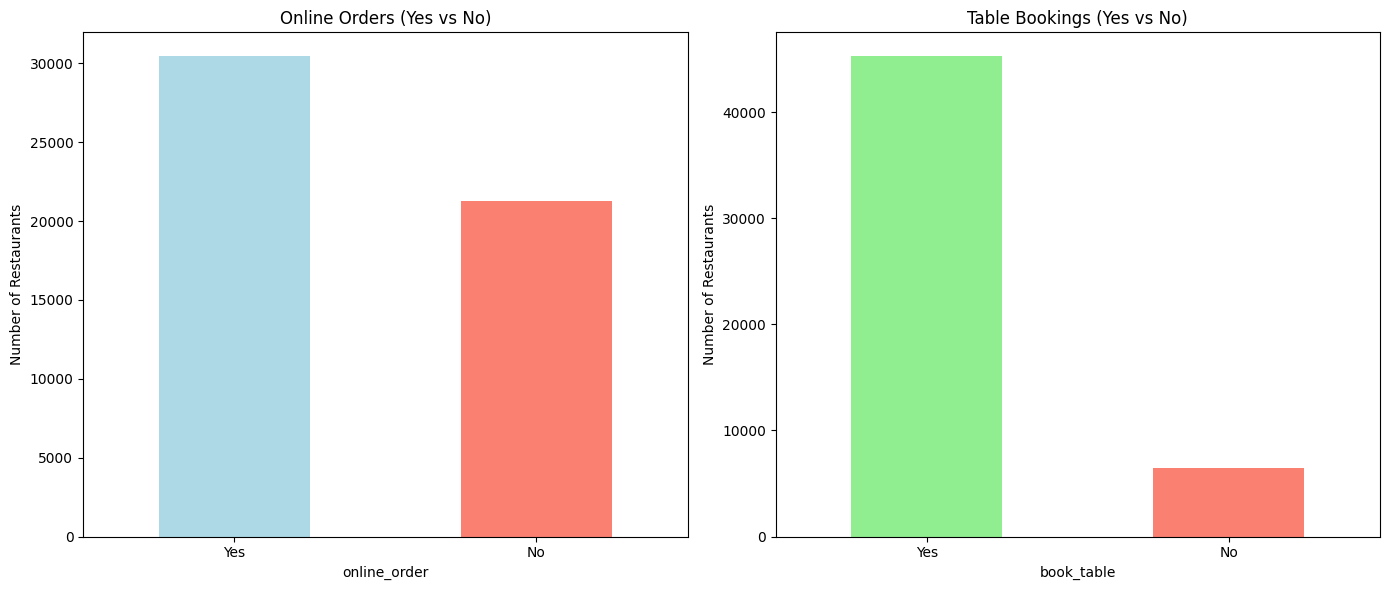

In [468]:
online_order_counts = df['online_order'].value_counts()
book_table_counts = df['book_table'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the counts for online orders (Yes vs No)
online_order_counts.plot(kind='bar', ax=axes[0], color=['lightblue', 'salmon'])
axes[0].set_title('Online Orders (Yes vs No)')
axes[0].set_xticklabels(['Yes', 'No'], rotation=0)
axes[0].set_ylabel('Number of Restaurants')

# Plot the counts for table bookings (Yes vs No)
book_table_counts.plot(kind='bar', ax=axes[1], color=['lightgreen', 'salmon'])
axes[1].set_title('Table Bookings (Yes vs No)')
axes[1].set_xticklabels(['Yes', 'No'], rotation=0)
axes[1].set_ylabel('Number of Restaurants')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

### Extracting the rating

The ratings is :
* a string of form: digit.digit/5
* a null values (exists but is not recorded)
* 'NEW' -> Restaurant is new, and no rating exists

Goal is to extract the 'digit.digit' form and for the NEW we will replace it will NULL.<br>
Later we will drop all the null values

In [469]:
def extract_rating(rating:str) -> float:
    ''' 
    This function takes the rating in the dataset (which is a string) and it converts the rating to a float number
    '''
    # Check if the rating matches the format digit.digit/5
    if re.match(r'^\d+\.\d+/5$', str(rating)):
        return float(rating.split('/')[0])
    else:
        return None

In [470]:
# Initial data situation
print(f'Number of rows with initially NULL values {df['rate'].isnull().sum()}')
print(f"Number of rows with initially NEW value: {len(df[df['rate'] == 'NEW'])}")

# Performing the cleaning
print(f'Type for the rate before processing : {type(df['rate'][0])}')
df['Rating'] = df['rate'].apply(lambda x: extract_rating(x))
print(f'Type for the rate after processing : {type(df["Rating"][0])}')

# Removing all the null values that are now present
print(f"Shape of the raw dataframe is {df.shape}")
df.dropna(subset=['Rating'], axis=0, inplace=True) #dropping all the rows where the rating is null (These were initially empty or NEW)
print(f"Shape of the dataframe after dropping null values is {df.shape}")
df.drop(['rate'],axis=1,inplace=True)

Number of rows with initially NULL values 7775
Number of rows with initially NEW value: 2208
Type for the rate before processing : <class 'str'>
Type for the rate after processing : <class 'numpy.float64'>
Shape of the raw dataframe is (51717, 12)
Shape of the dataframe after dropping null values is (21288, 12)


In [471]:
df.head()

,address,name,online_order,book_table,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list,Rating
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",4.1
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",4.1
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",3.8
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",3.7
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",3.8


### Plotting the average rating of the restaurant in each location

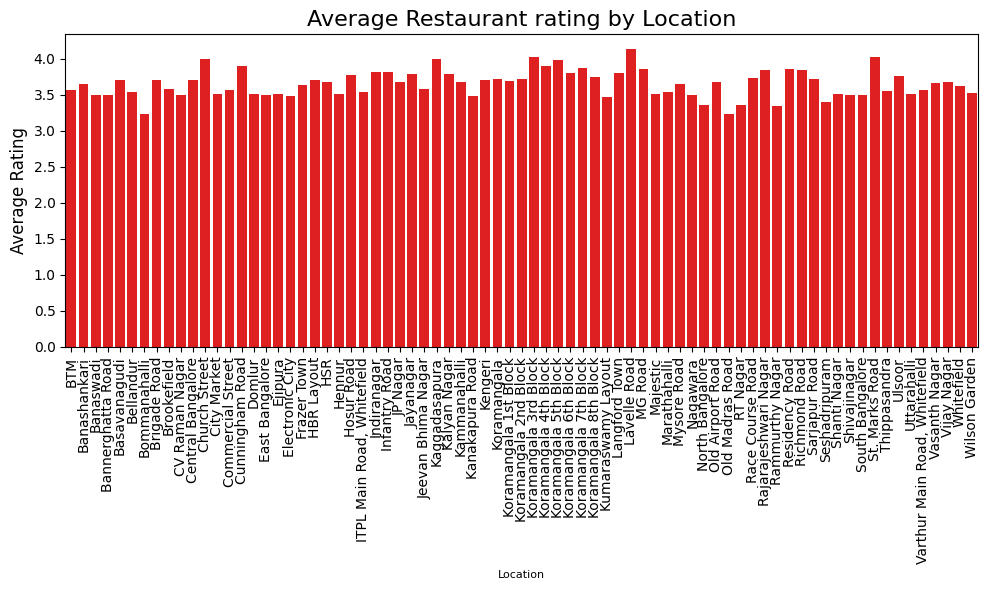

In [472]:
average_rating = df.groupby('location')['Rating'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=average_rating, x='location', y='Rating',color="Red")

# Adding title and labels
plt.title('Average Restaurant rating by Location', fontsize=16)
plt.xlabel('Location', fontsize=8)
plt.ylabel('Average Rating', fontsize=12)

# Rotating x-axis labels for better readability if needed
plt.xticks(rotation=90)

# Show the plot
plt.tight_layout()
plt.show()

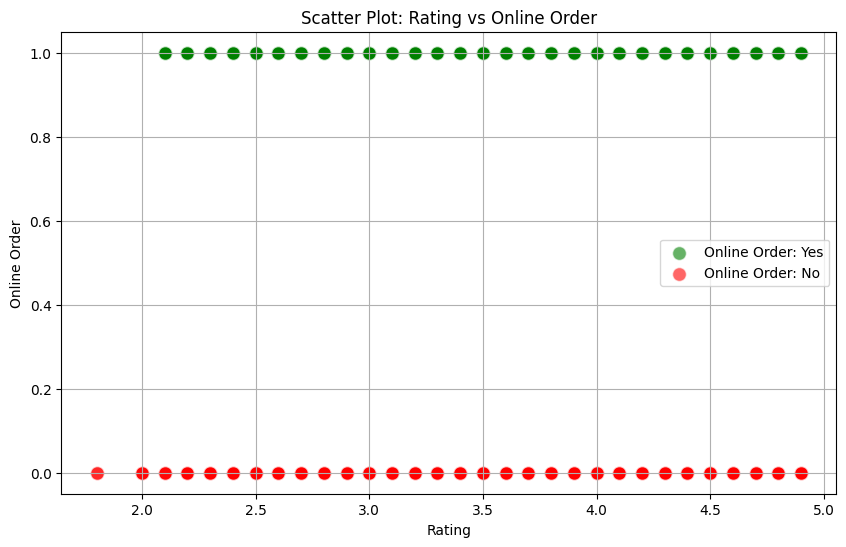

In [473]:
plt.figure(figsize=(10, 6))

# Plot for Online Order = 1 (Yes)
plt.scatter(df[df['online_order'] == 1]['Rating'], df[df['online_order'] == 1]['online_order'], 
            color='g', label='Online Order: Yes', alpha=0.6, edgecolors='w', s=100)

# Plot for Online Order = 0 (No)
plt.scatter(df[df['online_order'] == 0]['Rating'], df[df['online_order'] == 0]['online_order'], 
            color='r', label='Online Order: No', alpha=0.6, edgecolors='w', s=100)

plt.title('Scatter Plot: Rating vs Online Order')
plt.xlabel('Rating')
plt.ylabel('Online Order')
plt.legend()
plt.grid(True)
plt.show()

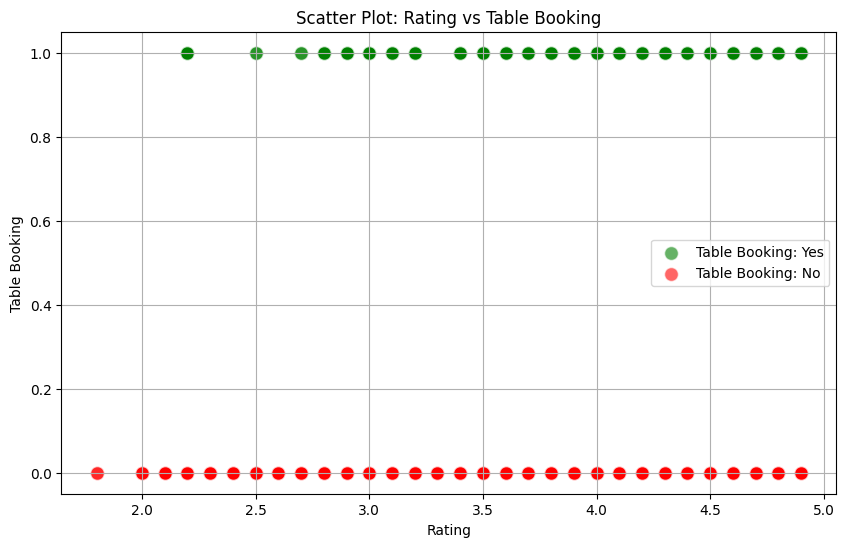

In [474]:
plt.figure(figsize=(10, 6))
plt.scatter(df[df['book_table'] == 1]['Rating'], df[df['book_table'] == 1]['book_table'], 
            color='g', label='Table Booking: Yes', alpha=0.6, edgecolors='w', s=100)
plt.scatter(df[df['book_table'] == 0]['Rating'], df[df['book_table'] == 0]['book_table'], 
            color='r', label='Table Booking: No', alpha=0.6, edgecolors='w', s=100)

plt.title('Scatter Plot: Rating vs Table Booking')
plt.xlabel('Rating')
plt.ylabel('Table Booking')
plt.legend()
plt.grid(True)
plt.show()

### Computing the price per head

Currently, the dataset has the price for 2 people, which is in the string format, we will compute the price per head, by:
1. Converting the number to float
2. Dividing by 2 (assuming the price is equally split between the two people)

In [475]:
def price_per_head(price: str) -> float:
    ''' 
    This function takes the approx cost for two people in the dataset (which is a string), 
    converts it to a float number, then divides by 2 to get the cost per head.
    '''
    if ',' in price:
        price = price.replace(',', '')  # Reassign the modified string to price
    return float(price) / 2  # Convert the cleaned price to float and divide by 2

In [476]:
# Dropping the null values
print(f"Number of rows initially with NULL Values : {df['approx_cost(for two people)'].isnull().sum()}")
print(f"Shape of the dataframe before dropping null values is {df.shape}")
df.dropna(subset=['approx_cost(for two people)'], axis=0, inplace= True)
print(f"Shape of the dataframe after dropping null values is {df.shape}")

# Computing the price per head
df['Price Per Head'] = df['approx_cost(for two people)'].apply(lambda x: price_per_head(x))
df.drop(['approx_cost(for two people)'],axis=1,inplace=True)

Number of rows initially with NULL Values : 75
Shape of the dataframe before dropping null values is (21288, 11)
Shape of the dataframe after dropping null values is (21213, 11)


In [477]:
df.head()

,address,name,online_order,book_table,votes,location,rest_type,cuisines,reviews_list,Rating,Price Per Head
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese","[('Rated 4.0', 'RATED\n A beautiful place to ...",4.1,400.0
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai","[('Rated 4.0', 'RATED\n Had been here for din...",4.1,400.0
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian","[('Rated 3.0', ""RATED\n Ambience is not that ...",3.8,400.0
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,88,Banashankari,Quick Bites,"South Indian, North Indian","[('Rated 4.0', ""RATED\n Great food and proper...",3.7,150.0
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani","[('Rated 4.0', 'RATED\n Very good restaurant ...",3.8,300.0


### Plotting the average price per head in each location

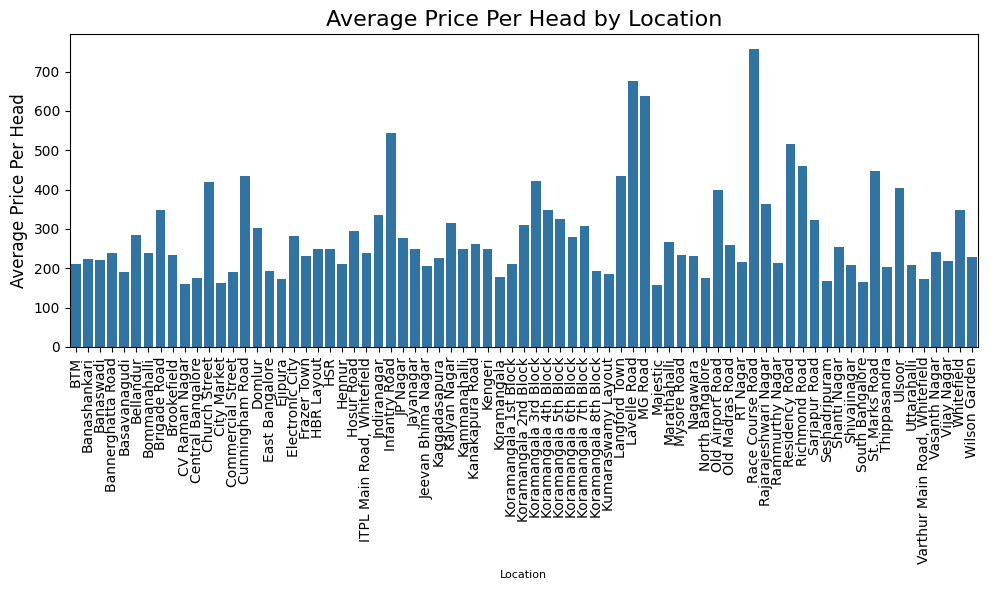

In [478]:
average_price_per_head = df.groupby('location')['Price Per Head'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=average_price_per_head, x='location', y='Price Per Head')

# Adding title and labels
plt.title('Average Price Per Head by Location', fontsize=16)
plt.xlabel('Location', fontsize=8)
plt.ylabel('Average Price Per Head', fontsize=12)

# Rotating x-axis labels for better readability if needed
plt.xticks(rotation=90)

# Show the plot
plt.tight_layout()
plt.show()

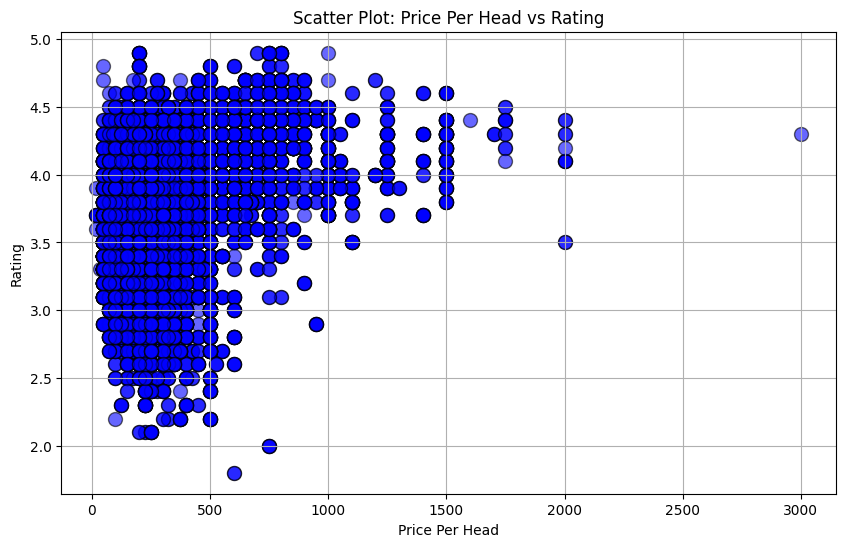

In [479]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Price Per Head'], df['Rating'], alpha=0.6, color='b', edgecolors='black', s=100)
plt.title('Scatter Plot: Price Per Head vs Rating')
plt.xlabel('Price Per Head')
plt.ylabel('Rating')
plt.grid(True)
plt.show()

### Getting all the unique Restaurant Categories

In [480]:
print(f"Number of rows initially with NULL Values : {df['rest_type'].isnull().sum()}")
print(f"Shape of the dataframe before dropping null values is {df.shape}")
df.dropna(subset=['rest_type'], axis=0, inplace= True)
print(f"Shape of the dataframe after dropping null values is {df.shape}")

Number of rows initially with NULL Values : 85
Shape of the dataframe before dropping null values is (21213, 11)
Shape of the dataframe after dropping null values is (21128, 11)


In [481]:
all_categories = []  # To store all unique categories

for category in df['rest_type'].unique().tolist():
    try:
        if ',' in category:
            categories = category.split(', ')
            all_categories.extend(categories)
        else:
            all_categories.append(category)
    except Exception as e:
        print(f'Category : {category}')
        print(f"Error occurred: {e}")

all_categories = list(set(all_categories))
print(f'Total number of restaurant types {len(all_categories)}')
all_categories

Total number of restaurant types 24


['Cafe',
 'Sweet Shop',
 'Food Truck',
 'Microbrewery',
 'Casual Dining',
 'Pub',
 'Bar',
 'Beverage Shop',
 'Meat Shop',
 'Bhojanalya',
 'Quick Bites',
 'Dessert Parlor',
 'Lounge',
 'Irani Cafee',
 'Fine Dining',
 'Takeaway',
 'Mess',
 'Delivery',
 'Club',
 'Bakery',
 'Kiosk',
 'Food Court',
 'Dhaba',
 'Confectionery']

We can see there are several categories that we can group as similar<br>
examples :
1. Cafe and Irani Cafee can be grouped together, as in the end, both are just cafe's.
2. Bar, Pub and Microbrewery can be grouped together, as all the serve alcohol.

The final mapping that can be made, by grouping similar categories together is :
* Cafe, Irani Cafee -> Cafe
* Sweet Shop, Confectionery -> Sweets
* Food Truck, Takeaway, Delivery -> FastFood
* Microbrewery, Pub, Bar -> Bar
* Casual Dining, Fine Dining -> Dining
* Bhojanalya, Dhaba, Mess -> Indian
* Quick Bites, Food Court, Kiosk -> Snacks
* Bakery, Dessert Parlor -> Bakery
* Lounge, Club -> Lounge

In [482]:
restaurant_type_mapping = {
'Lounge' : ['Lounge','Club'],
'Bar' : ['Bar','Pub','Microbrewery'],
'Dining' : ['Dining','Casual Dining','Fine Dining'],
'Sweets' : ['Sweet Shop','Confectionery'],
'FastFood' : ['Food Truck','Takeaway','Delivery'],
'Indian' : ['Bhojanalya','Dhaba','Mess'],
'Snacks' : ['Quick Bites','Food Court','Kiosk'],
'Bakery' : ['Bakery','Dessert Parlor'],
'Cafe' : ['Cafe', 'Irani Cafee']
}


In [483]:
def get_restaurant_type_group(restaurant_type):
    groups = []
    types = restaurant_type.split(', ')
    
    for type_name, group_list in restaurant_type_mapping.items():
        if any(rest_type in types for rest_type in group_list):
            groups.append(type_name)
    
    # Remove duplicates and return the groups
    return ', '.join(groups) if groups else 'Miscellaneous'

In [484]:
df['rest_type_group'] = df['rest_type'].apply(get_restaurant_type_group)
df.drop(['rest_type'],axis=1,inplace=True)

In [485]:
df.head()

,address,name,online_order,book_table,votes,location,cuisines,reviews_list,Rating,Price Per Head,rest_type_group
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,775,Banashankari,"North Indian, Mughlai, Chinese","[('Rated 4.0', 'RATED\n A beautiful place to ...",4.1,400.0,Dining
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,787,Banashankari,"Chinese, North Indian, Thai","[('Rated 4.0', 'RATED\n Had been here for din...",4.1,400.0,Dining
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,918,Banashankari,"Cafe, Mexican, Italian","[('Rated 3.0', ""RATED\n Ambience is not that ...",3.8,400.0,"Dining, Cafe"
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,88,Banashankari,"South Indian, North Indian","[('Rated 4.0', ""RATED\n Great food and proper...",3.7,150.0,Snacks
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,166,Basavanagudi,"North Indian, Rajasthani","[('Rated 4.0', 'RATED\n Very good restaurant ...",3.8,300.0,Dining


### Analyzing the Restaurant type

In [486]:
most_common_type = df.explode('rest_type_group') .groupby('location')['rest_type_group'].value_counts().reset_index(name='count')
most_common_type = most_common_type.loc[most_common_type.groupby('location')['count'].idxmax()]
print(f'The most common cuisines in Bangalore is : \n {most_common_type['rest_type_group'].unique()}')

The most common cuisines in Bangalore is : 
 ['Snacks' 'FastFood' 'Dining' 'Cafe' 'Miscellaneous' 'Bar, Dining'
 'Bakery' 'Sweets']


Analyzing the market hold of each restaurant type

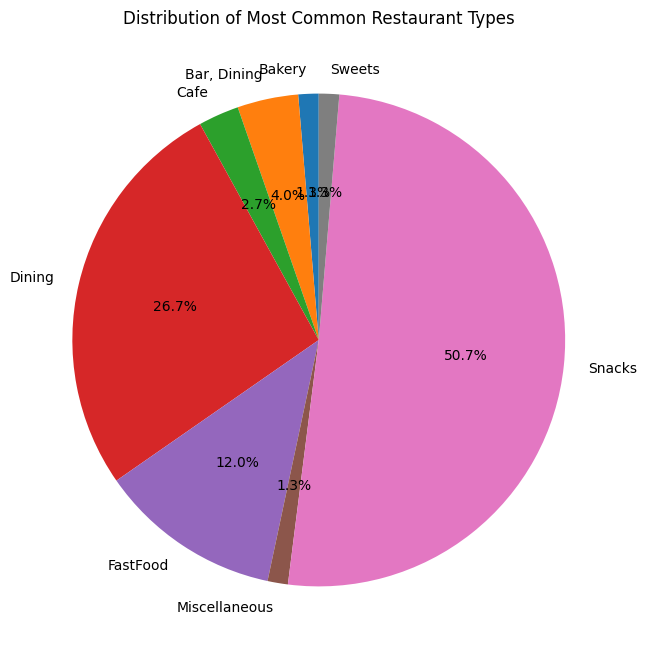

In [487]:
plt.figure(figsize=(8, 8))
most_common_type.groupby('rest_type_group').size().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Most Common Restaurant Types')
plt.ylabel('')
plt.show()

Which restaurant type is common in which location by how much

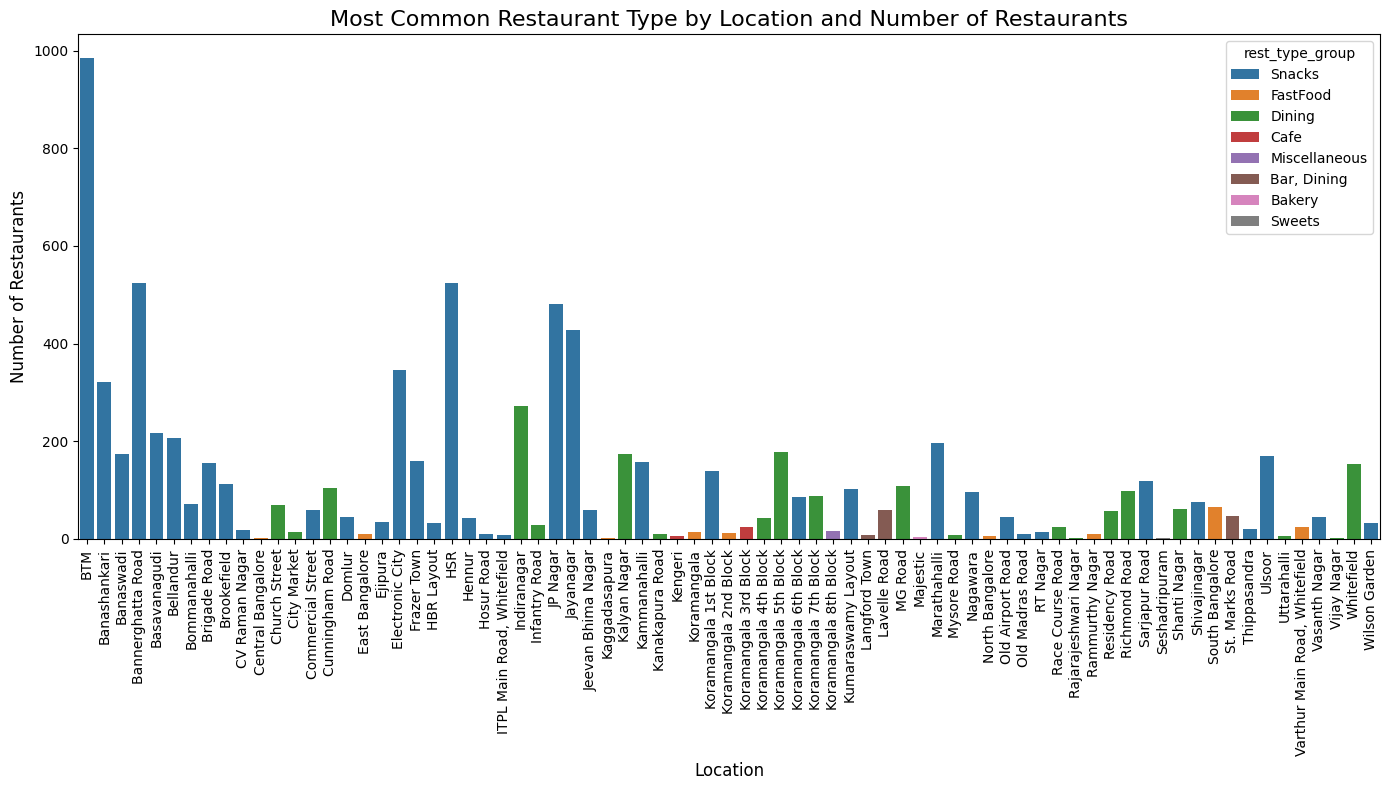

In [488]:
plt.figure(figsize=(14, 8))  # Adjust size for better visibility
sns.barplot(data=most_common_type, x='location', y='count', hue='rest_type_group')

# Customizing the plot
plt.title('Most Common Restaurant Type by Location and Number of Restaurants', fontsize=16)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility
plt.tight_layout()  # Adjust layout to prevent clipping

# Show plot
plt.show()

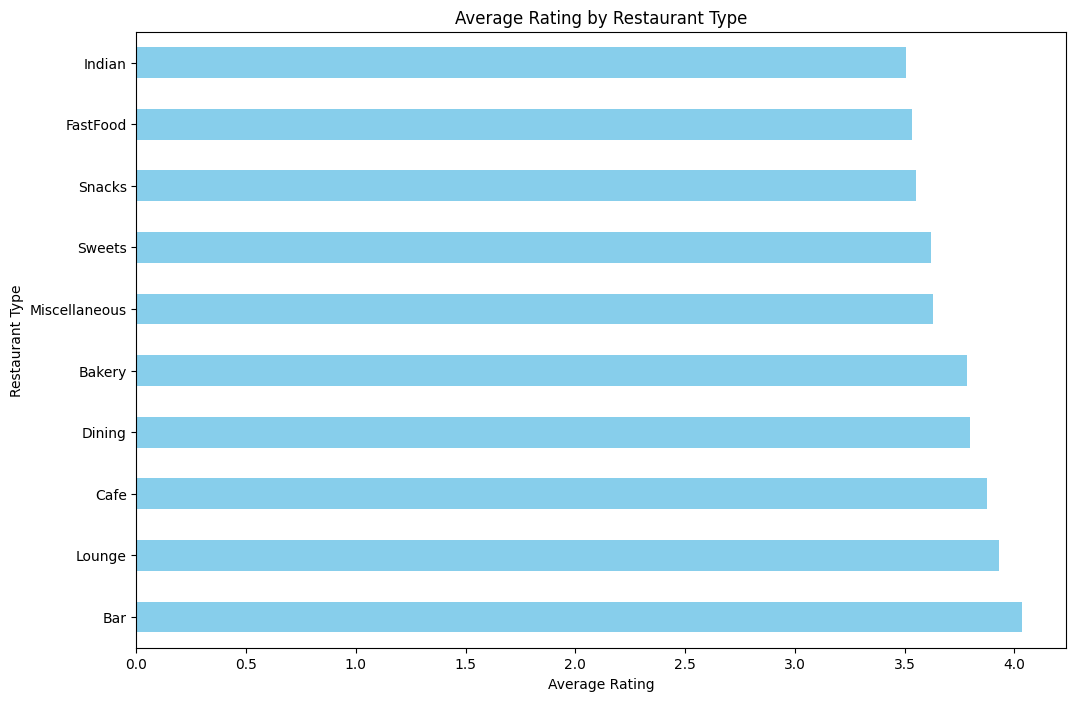

In [489]:
# Explode the 'rest_type_group' column into individual types
df_exploded = df['rest_type_group'].str.split(', ').explode()

# Convert the exploded column into a DataFrame
df_exploded = df_exploded.to_frame(name='rest_type_group')

# Align the 'Rating' column with the exploded data
df_exploded['Rating'] = df.loc[df_exploded.index, 'Rating'].values

# Calculate the average rating for each restaurant type
avg_rating_by_type = df_exploded.groupby('rest_type_group')['Rating'].mean().sort_values(ascending=False)

# Plot the average rating for each restaurant type
plt.figure(figsize=(12, 8))
avg_rating_by_type.plot(kind='barh', color='skyblue')
plt.title('Average Rating by Restaurant Type')
plt.xlabel('Average Rating')
plt.ylabel('Restaurant Type')
plt.show()

### Getting all the unique Cuisines

In [490]:
print(f"Number of rows initially with NULL Values : {df['cuisines'].isnull().sum()}")
print(f"Shape of the dataframe before dropping null values is {df.shape}")
df.dropna(subset=['cuisines'], axis=0, inplace= True)
print(f"Shape of the dataframe after dropping null values is {df.shape}")

Number of rows initially with NULL Values : 4
Shape of the dataframe before dropping null values is (21128, 11)
Shape of the dataframe after dropping null values is (21124, 11)


In [491]:
all_cuisines = []  # To store all unique categories

for cuisines in df['cuisines'].unique().tolist():
    try:
        if ',' in cuisines:
            cuisines = cuisines.split(', ')
            all_cuisines.extend(cuisines)
        else:
            all_cuisines.append(cuisines)
    except Exception as e:
        print(f'Cuisine : {cuisines}')
        print(f"Error occurred: {e}")

all_cuisines = list(set(all_cuisines))
print(f'Total number of cuisines {len(all_cuisines)}')
all_cuisines

Total number of cuisines 104


['Tibetan',
 'Goan',
 'German',
 'Pizza',
 'Portuguese',
 'Sri Lankan',
 'Mughlai',
 'Jewish',
 'Japanese',
 'Steak',
 'Tamil',
 'Greek',
 'Grill',
 'Modern Indian',
 'Andhra',
 'Naga',
 'Fast Food',
 'Rajasthani',
 'Vegan',
 'Russian',
 'Parsi',
 'Chettinad',
 'Ice Cream',
 'North Eastern',
 'Kerala',
 'Finger Food',
 'Burger',
 'Mediterranean',
 'Cafe',
 'Australian',
 'Maharashtrian',
 'Kashmiri',
 'Pan Asian',
 'Nepalese',
 'Arabian',
 'Afghani',
 'Mongolian',
 'Mexican',
 'Vietnamese',
 'Singaporean',
 'Beverages',
 'Raw Meats',
 'Biryani',
 'French',
 'Bengali',
 'Malaysian',
 'Kebab',
 'Bohri',
 'Belgian',
 'Juices',
 'Salad',
 'Turkish',
 'Seafood',
 'Lebanese',
 'Roast Chicken',
 'Paan',
 'Hyderabadi',
 'Cantonese',
 'Gujarati',
 'Coffee',
 'Asian',
 'North Indian',
 'Konkan',
 'Afghan',
 'Drinks Only',
 'Indonesian',
 'Momos',
 'European',
 'African',
 'Charcoal Chicken',
 'Bar Food',
 'Tex-Mex',
 'Iranian',
 'British',
 'Oriya',
 'Bubble Tea',
 'American',
 'Rolls',
 'Italia

We can again group the cuisines, like we had grouped the restaurant types

* Mughlai, Modern Indian, Andhra, Naga, Rajasthani, Chettinad, North Indian, South Indian, Hyderabadi, Gujarati, Konkan, Awadhi, Lucknowi, Biryani, Maharashtrian, Kashmiri, Tamil, Kerala -> Indian

* Tibetan, Sri Lankan, Japanese, Pan Asian, Cantonese, Korean, Chinese, Mongolian, Vietnamese, Singaporean, Nepalese, Burmese, Indonesian, Thai -> Asian

* Italian, French, Greek, Spanish, Belgian, British, German, Portuguese, Russian -> European

* Lebanese, Turkish, Arabian, Iranian, Israeli, Afghan -> Middle Eastern

* American, Tex-Mex, Steak, Burger, Fast Food, Sandwich, Hot Dogs -> American*

* Greek, Lebanese, Turkish -> Mediterranean

* Mexican, South American, Brazilian, Argentine -> Latin American

* African, Ethiopian -> African

* Seafood, Fish & Chips, Charcoal Chicken, Roast Chicken -> Seafood & Fish

* Vegan, Healthy Food, Salad, Juices, Beverages -> Healthy & Vegan

* Fast Food, Street Food, Food Truck, Quick Bites, Kebab, Wraps, Roll, Momos, Finger Food, Bar Food -> Fast Food & Quick Bites

* Ice Cream, Mithai, Desserts, Paan, Bakery, Confectionery, Sweet Shop, Chocolate -> Desserts & Sweets

* Raw Meats, Grill, Barbecue (BBQ)-> Other Specialized Cuisines

* Food Court, Kiosk, Food Truck, Mess, Bhojanalya, Dhaba, Kiosk -> Street/Local

* Beverages, Drinks Only, Juice Bar, Paan, Bubble Tea, Tea, Coffee -> Drinks

In [492]:
cuisine_group_mapping = {
    'Indian': ['Mughlai', 'Modern Indian', 'Andhra', 'Naga', 'Rajasthani', 'Chettinad', 'North Indian', 'South Indian', 'Hyderabadi', 'Gujarati', 'Konkan', 'Awadhi', 'Lucknowi', 'Biryani', 'Maharashtrian', 'Kashmiri', 'Tamil', 'Kerala'],
    'Asian': ['Tibetan', 'Sri Lankan', 'Japanese', 'Pan Asian', 'Cantonese', 'Korean', 'Chinese', 'Mongolian', 'Vietnamese', 'Singaporean', 'Nepalese', 'Burmese', 'Indonesian', 'Thai'],
    'European': ['Italian', 'French', 'Greek', 'Spanish', 'Belgian', 'British', 'German', 'Portuguese', 'Russian'],
    'Middle Eastern': ['Lebanese', 'Turkish', 'Arabian', 'Iranian', 'Israeli', 'Afghan'],
    'American': ['American', 'Tex-Mex', 'BBQ', 'Steak', 'Burger', 'Fast Food', 'Sandwich', 'Hot Dogs'],
    'Mediterranean': ['Greek', 'Lebanese', 'Turkish'],
    'Latin American': ['Mexican', 'South American', 'Brazilian', 'Argentine'],
    'African': ['African', 'Ethiopian'],
    'Seafood & Fish': ['Seafood', 'Fish & Chips', 'Charcoal Chicken', 'Roast Chicken'],
    'Healthy & Vegan': ['Vegan', 'Healthy Food', 'Salad', 'Juices'],
    'Fast Food & Quick Bites': ['Fast Food', 'Street Food', 'Food Truck', 'Quick Bites', 'Kebab', 'Wraps', 'Roll', 'Momos', 'Finger Food', 'Bar Food'],
    'Desserts & Sweets': ['Ice Cream', 'Mithai', 'Desserts', 'Paan', 'Bakery', 'Confectionery', 'Sweet Shop', 'Chocolate'],
    'Other Specialized Cuisines': ['Raw Meats', 'Grill', 'Barbecue (BBQ)'],
    'Street/Local': ['Food Court', 'Kiosk', 'Food Truck', 'Mess', 'Bhojanalya', 'Dhaba', 'Kiosk'],
    'Miscellaneous': ['Beverages', 'Drinks Only', 'Juice Bar',  'Bubble Tea', 'Tea', 'Coffee']
}

In [493]:
def get_cuisine_group(cuisines):
    cuisines_list = cuisines.split(', ')
    groups = []

    for group, items in cuisine_group_mapping.items():
        if any(cuisine in cuisines_list for cuisine in items):
            groups.append(group)
    return ', '.join(groups) if groups else 'Miscellaneous'

In [494]:
df['cuisine_group'] = df['cuisines'].apply(get_cuisine_group)
df.drop(['cuisines'],axis=1,inplace=True)

In [495]:
df.head()

,address,name,online_order,book_table,votes,location,reviews_list,Rating,Price Per Head,rest_type_group,cuisine_group
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,775,Banashankari,"[('Rated 4.0', 'RATED\n A beautiful place to ...",4.1,400.0,Dining,"Indian, Asian"
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,787,Banashankari,"[('Rated 4.0', 'RATED\n Had been here for din...",4.1,400.0,Dining,"Indian, Asian"
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,918,Banashankari,"[('Rated 3.0', ""RATED\n Ambience is not that ...",3.8,400.0,"Dining, Cafe","European, Latin American"
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,88,Banashankari,"[('Rated 4.0', ""RATED\n Great food and proper...",3.7,150.0,Snacks,Indian
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,166,Basavanagudi,"[('Rated 4.0', 'RATED\n Very good restaurant ...",3.8,300.0,Dining,Indian


### Analyzing the cuisines

In [496]:
df_exploded = df['cuisine_group'].str.split(', ').explode()
df_exploded = df_exploded.to_frame(name='cuisine_group')
df_exploded['location'] = df.loc[df_exploded.index, 'location'].values
most_common_cuisine = df_exploded.explode('cuisine_group').groupby('location')['cuisine_group'].value_counts().reset_index(name='count')
most_common_cuisine = most_common_cuisine.loc[most_common_cuisine.groupby('location')['count'].idxmax()]
print(f'The most common cuisines in Bangalore is : \n {most_common_cuisine['cuisine_group'].unique()}')

The most common cuisines in Bangalore is : 
 ['Indian' 'American' 'Fast Food & Quick Bites' 'Asian' 'Miscellaneous'
 'European' 'Desserts & Sweets']


Analyzing the market hold of the most common cuisines

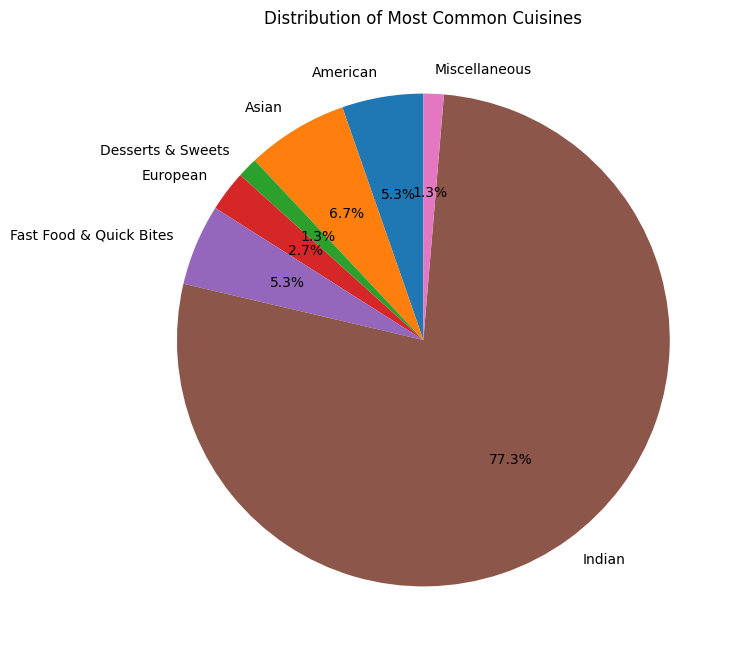

In [497]:
plt.figure(figsize=(8, 8))
most_common_cuisine.groupby('cuisine_group').size().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Most Common Cuisines')
plt.ylabel('')
plt.show()

Which cuisine has how many restaurant in which area

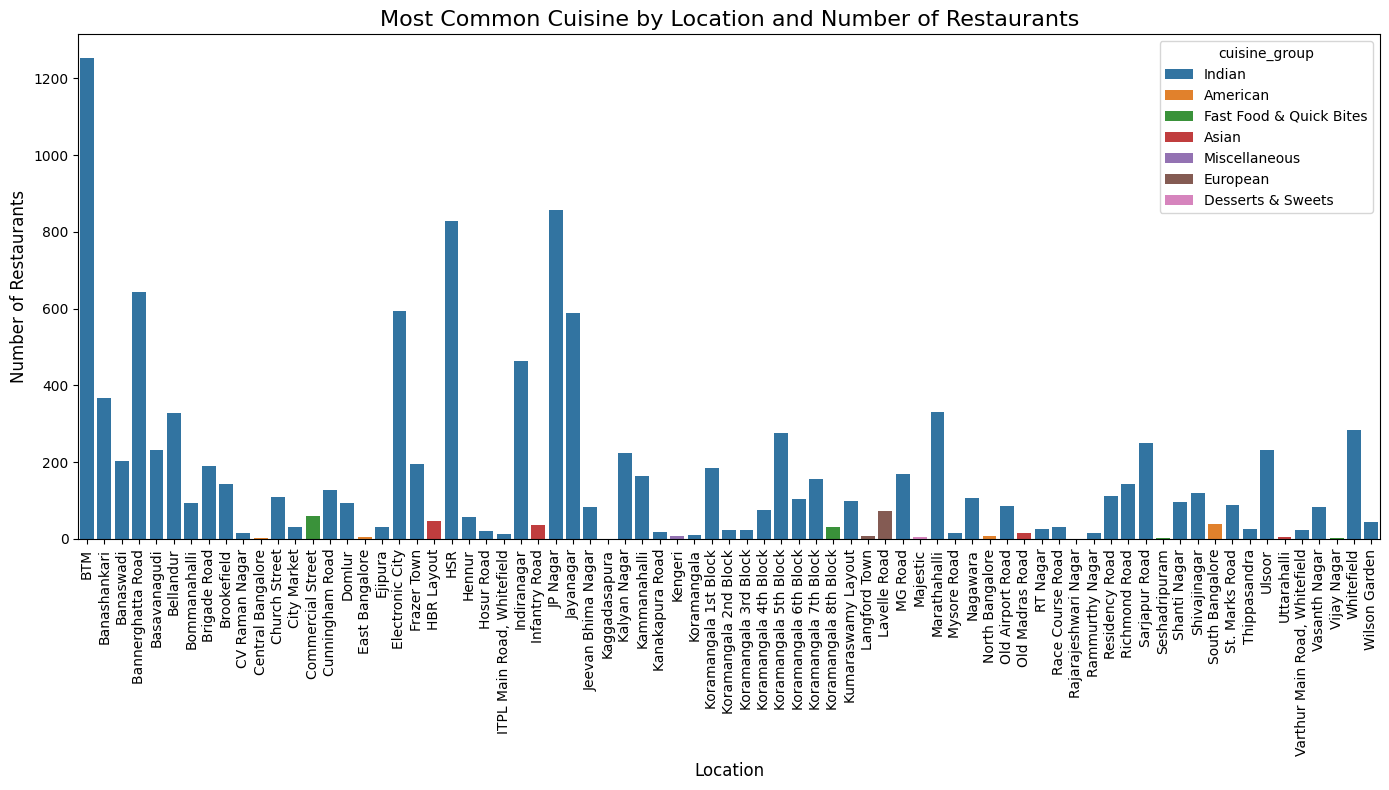

In [498]:
plt.figure(figsize=(14, 8))  # Adjust size for better visibility
sns.barplot(data=most_common_cuisine, x='location', y='count', hue='cuisine_group')

# Customizing the plot
plt.title('Most Common Cuisine by Location and Number of Restaurants', fontsize=16)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility
plt.tight_layout()  # Adjust layout to prevent clipping

# Show plot
plt.show()

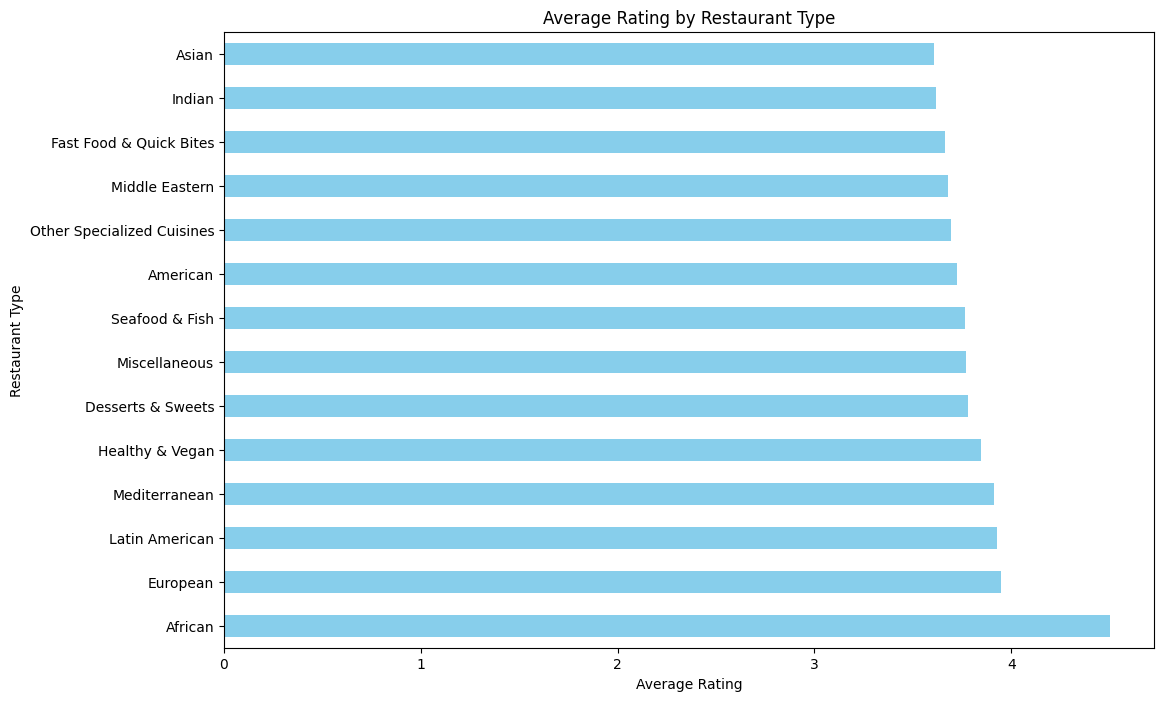

In [499]:
df_exploded = df['cuisine_group'].str.split(', ').explode()
df_exploded = df_exploded.to_frame(name='cuisine_group')
df_exploded['Rating'] = df.loc[df_exploded.index, 'Rating'].values
avg_rating_by_cuisine = df_exploded.groupby('cuisine_group')['Rating'].mean().sort_values(ascending=False)

# Plot the average rating for each restaurant type
plt.figure(figsize=(12, 8))
avg_rating_by_cuisine.plot(kind='barh', color='skyblue')
plt.title('Average Rating by Restaurant Type')
plt.xlabel('Average Rating')
plt.ylabel('Restaurant Type')
plt.show()

### Labelling the locations

In [500]:
locations = df['location'].unique().tolist()
print(f'The total number of locations covered : {len(locations)}')
locations

The total number of locations covered : 75


['Banashankari',
 'Basavanagudi',
 'Mysore Road',
 'Jayanagar',
 'Kumaraswamy Layout',
 'Rajarajeshwari Nagar',
 'Vijay Nagar',
 'Uttarahalli',
 'JP Nagar',
 'South Bangalore',
 'City Market',
 'Bannerghatta Road',
 'BTM',
 'Kanakapura Road',
 'Bommanahalli',
 'Electronic City',
 'Wilson Garden',
 'Shanti Nagar',
 'Koramangala 5th Block',
 'Richmond Road',
 'HSR',
 'Koramangala 7th Block',
 'Bellandur',
 'Sarjapur Road',
 'Marathahalli',
 'Whitefield',
 'East Bangalore',
 'Old Airport Road',
 'Indiranagar',
 'Koramangala 1st Block',
 'Frazer Town',
 'MG Road',
 'Brigade Road',
 'Lavelle Road',
 'Church Street',
 'Ulsoor',
 'Residency Road',
 'Shivajinagar',
 'Infantry Road',
 'St. Marks Road',
 'Cunningham Road',
 'Race Course Road',
 'Commercial Street',
 'Vasanth Nagar',
 'Domlur',
 'Koramangala 8th Block',
 'Ejipura',
 'Jeevan Bhima Nagar',
 'Old Madras Road',
 'Seshadripuram',
 'Kammanahalli',
 'Koramangala 6th Block',
 'Majestic',
 'Langford Town',
 'Central Bangalore',
 'Brookefi

In [501]:
location_mapping = {location: index + 1 for index, location in enumerate(locations)}
location_mapping

{'Banashankari': 1,
 'Basavanagudi': 2,
 'Mysore Road': 3,
 'Jayanagar': 4,
 'Kumaraswamy Layout': 5,
 'Rajarajeshwari Nagar': 6,
 'Vijay Nagar': 7,
 'Uttarahalli': 8,
 'JP Nagar': 9,
 'South Bangalore': 10,
 'City Market': 11,
 'Bannerghatta Road': 12,
 'BTM': 13,
 'Kanakapura Road': 14,
 'Bommanahalli': 15,
 'Electronic City': 16,
 'Wilson Garden': 17,
 'Shanti Nagar': 18,
 'Koramangala 5th Block': 19,
 'Richmond Road': 20,
 'HSR': 21,
 'Koramangala 7th Block': 22,
 'Bellandur': 23,
 'Sarjapur Road': 24,
 'Marathahalli': 25,
 'Whitefield': 26,
 'East Bangalore': 27,
 'Old Airport Road': 28,
 'Indiranagar': 29,
 'Koramangala 1st Block': 30,
 'Frazer Town': 31,
 'MG Road': 32,
 'Brigade Road': 33,
 'Lavelle Road': 34,
 'Church Street': 35,
 'Ulsoor': 36,
 'Residency Road': 37,
 'Shivajinagar': 38,
 'Infantry Road': 39,
 'St. Marks Road': 40,
 'Cunningham Road': 41,
 'Race Course Road': 42,
 'Commercial Street': 43,
 'Vasanth Nagar': 44,
 'Domlur': 45,
 'Koramangala 8th Block': 46,
 'Ej

In [502]:
def encode_location(location):
    if location in location_mapping:
        return location_mapping[location]
    else:
        return len(location_mapping) + 1 

In [503]:
df['Location'] = df['location'].apply(encode_location)
df.drop(['location'],axis=1,inplace=True)

In [504]:
df.head()

,address,name,online_order,book_table,votes,reviews_list,Rating,Price Per Head,rest_type_group,cuisine_group,Location
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,775,"[('Rated 4.0', 'RATED\n A beautiful place to ...",4.1,400.0,Dining,"Indian, Asian",1
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,787,"[('Rated 4.0', 'RATED\n Had been here for din...",4.1,400.0,Dining,"Indian, Asian",1
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,918,"[('Rated 3.0', ""RATED\n Ambience is not that ...",3.8,400.0,"Dining, Cafe","European, Latin American",1
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,88,"[('Rated 4.0', ""RATED\n Great food and proper...",3.7,150.0,Snacks,Indian,1
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,166,"[('Rated 4.0', 'RATED\n Very good restaurant ...",3.8,300.0,Dining,Indian,2
